In [458]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importa o dataset

In [459]:
df = pd.read_csv("dataset/dataset_regressao_polinomial.csv")

coluna_y = df.columns[-1]
print(coluna_y)

preco


### Tratamento do dataset
retira os outliers

In [460]:
while True:

    anterior = len(df)

    q25 = df[coluna_y].quantile(0.25)
    q75 = df[coluna_y].quantile(0.75)

    iqr = q75 - q25

    li = q25 - 1.5 * iqr
    ls = q75 + 1.5 * iqr

    df = df[(df[coluna_y] <= ls) & (df[coluna_y] >= li)]

    apos = len(df)

    if anterior == apos:
        break

print(len(df))

5000


Separa X e Y

In [461]:
x = df.drop(columns=coluna_y)
y = df[coluna_y]

Faz a tranformação polinomial

Separa uma parte para teste e uma parte para treino

In [462]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x = poly.fit_transform(x)

from sklearn.model_selection import train_test_split
x_tr, x_te, y_tr, y_te = train_test_split(x, y, test_size=0.2, random_state=42) 

### Treinamento do modelo

Seleciona o modelo e criar grid de hiperparametros

In [463]:
from sklearn import ensemble
modelo = ensemble.RandomForestRegressor(
    min_samples_split=2,
    max_features="sqrt"
    )

from sklearn.model_selection import GridSearchCV

hiper = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_leaf": [1, 2, 5]
    }

grid = GridSearchCV(
    estimator=modelo,
    param_grid=hiper,
    scoring="r2",
    cv=5
)

Treina o modelo

In [464]:
grid.fit(x_tr, y_tr)
modelo = grid

Plota o resultado

c:\Users\pedro\Projetos\PYTHON\regressão-scikit-learn\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


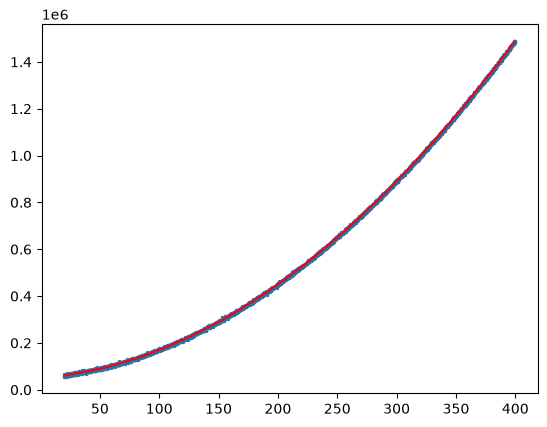

In [465]:
predição = modelo.predict(x_te)

plt.scatter(x[:,1], y, s=2)

lx = np.linspace(x_te[:,1].min(), x_te[:,1].max(), 500).reshape(-1, 1)
ly = modelo.predict(poly.transform(lx))

plt.plot(lx, ly ,color="red")

plt.show()

Mostra o resultado do modelo

In [ ]:
print("R2 =", modelo.score(x_te , y_te))

R2 = 0.9999395391230568
<class 'numpy.ndarray'>


In [483]:
print(modelo.n_features_in_)
print(x_tr.shape)


3
(4000, 3)
